In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)


In [3]:
longi = pd.read_csv('oasis_longitudinal.csv')
cross = pd.read_csv('oasis_cross-sectional.csv')

longi['SES'] = longi['SES'].fillna(longi['SES'].median())
longi['MMSE'] = longi['MMSE'].fillna(longi['MMSE'].median())
longi['MMSE'] = longi['MMSE'].fillna(longi['MMSE'].median())
cross['SES'] = cross['SES'].fillna(cross['SES'].median())
cross['MMSE'] = cross['MMSE'].fillna(cross['MMSE'].median())
cross['Educ'] = cross['Educ'].fillna(cross['Educ'].median())
cross['CDR'] = cross['CDR'].fillna(cross['CDR'].median())

cross_renamed = cross.rename(columns={'Educ': 'EDUC'})

features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X_longi = longi[features].fillna(longi.median(numeric_only=True))
y_longi = longi['CDR'].astype(str)
X_cross = cross_renamed[features].fillna(longi.median(numeric_only=True))
y_cross = cross_renamed['CDR'].astype(str)

clases_str = ['0.0', '0.5', '1.0', '2.0']
longi.isna().sum()

Subject ID    0
MRI ID        0
Group         0
Visit         0
MR Delay      0
Sex           0
Hand          0
Age           0
EDUC          0
SES           0
MMSE          0
CDR           0
eTIV          0
nWBV          0
ASF           0
dtype: int64

In [4]:
columnas_comunes = ['ID', 'Sex', 'Age', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
longi_renamed = longi.rename(columns={'EDUC': 'Educ', 'Subject ID': 'ID'})
df = pd.concat([cross[columnas_comunes], longi_renamed[columnas_comunes]], ignore_index=True)
features_df = ['Sex', 'Age', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
Xdf = df[features_df].fillna(longi.median(numeric_only=True))
ydf = df['CDR'].astype(str)
df.isna().sum()

ID      0
Sex     0
Age     0
SES     0
MMSE    0
CDR     0
eTIV    0
nWBV    0
ASF     0
dtype: int64

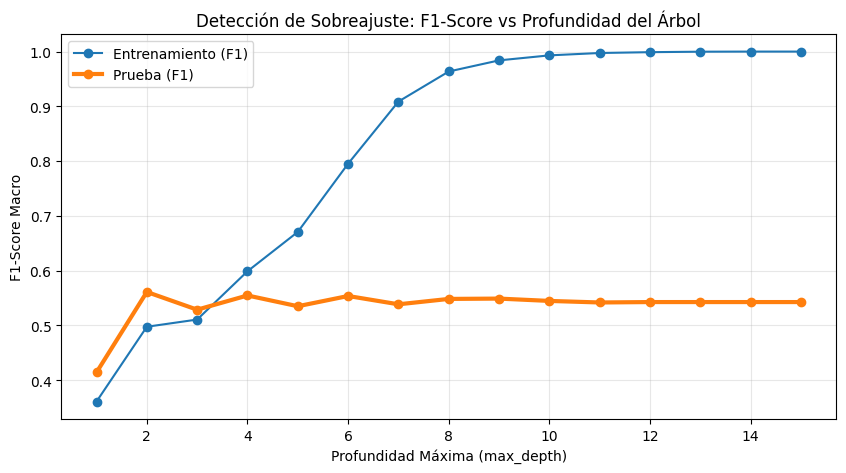

In [5]:
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X_longi)

profundidades = range(1, 16)
train_scores = []
test_scores = []

for d in profundidades:
    # Promediamos 10 iteraciones por cada profundidad
    t_iter, v_iter = [], []
    for i in range(10):
        xt, xv, yt, yv = train_test_split(X_prep, y_longi, test_size=0.2, random_state=i)
        dt = DecisionTreeClassifier(max_depth=d, random_state=42)
        dt.fit(xt, yt)
        t_iter.append(f1_score(yt, dt.predict(xt), average='macro'))
        v_iter.append(f1_score(yv, dt.predict(xv), average='macro'))
    train_scores.append(np.mean(t_iter))
    test_scores.append(np.mean(v_iter))

plt.figure(figsize=(10, 5))
plt.plot(profundidades, train_scores, label='Entrenamiento (F1)', marker='o')
plt.plot(profundidades, test_scores, label='Prueba (F1)', marker='o', linewidth=3)
plt.title("Detección de Sobreajuste: F1-Score vs Profundidad del Árbol")
plt.xlabel("Profundidad Máxima (max_depth)")
plt.ylabel("F1-Score Macro")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Calculando curva de complejidad...


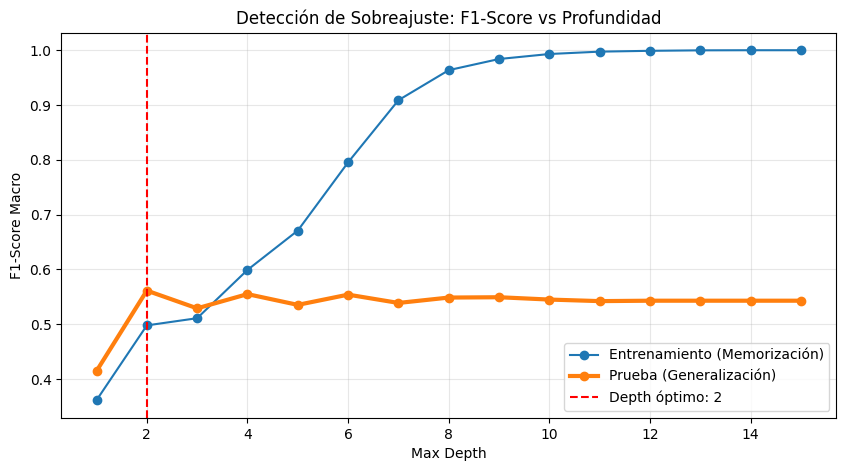

La profundidad recomendada para tu informe es: 2


In [10]:
mputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X_longi)

# --- PASO 2: BÚSQUEDA DEL DEPTH ÓPTIMO ---
depths = range(1, 16)
train_scores, test_scores = [], []

print("Calculando curva de complejidad...")
for d in depths:
    t_iter, v_iter = [], []
    for i in range(10): # 10 Validaciones independientes [4]
        xt, xv, yt, yv = train_test_split(X_prep, y_longi, test_size=0.2, random_state=i)
        
        # Modelo con balanceo de pesos por el desbalance de clases [8]
        dt = DecisionTreeClassifier(max_depth=d, random_state=42)
        dt.fit(xt, yt)
        
        t_iter.append(f1_score(yt, dt.predict(xt), average='macro'))
        v_iter.append(f1_score(yv, dt.predict(xv), average='macro'))
    
    train_scores.append(np.mean(t_iter))
    test_scores.append(np.mean(v_iter))

# El depth óptimo es donde el desempeño en prueba es máximo
opt_depth = depths[np.argmax(test_scores)]

# Visualización de la Curva de Complejidad [9]
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Entrenamiento (Memorización)', marker='o')
plt.plot(depths, test_scores, label='Prueba (Generalización)', marker='o', linewidth=3)
plt.axvline(opt_depth, color='red', linestyle='--', label=f'Depth óptimo: {opt_depth}')
plt.title("Detección de Sobreajuste: F1-Score vs Profundidad")
plt.xlabel("Max Depth")
plt.ylabel("F1-Score Macro")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"La profundidad recomendada para tu informe es: {opt_depth}")

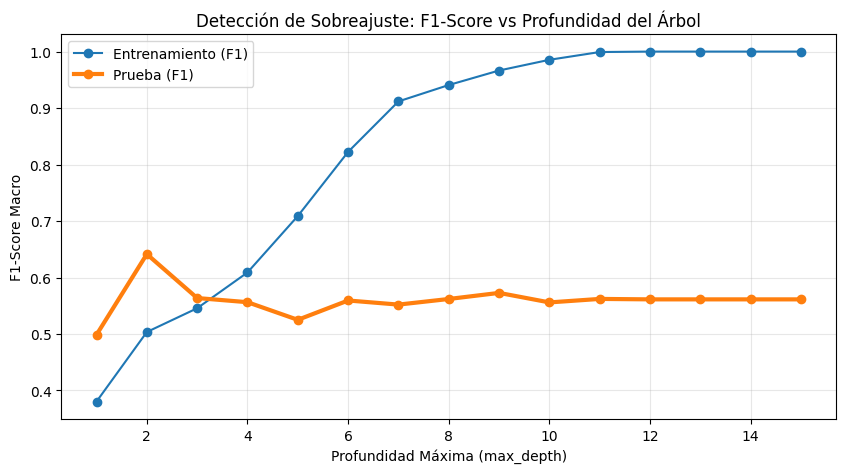

In [6]:
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X_cross)

profundidades = range(1, 16)
train_scores = []
test_scores = []

for d in profundidades:
    # Promediamos 10 iteraciones por cada profundidad
    t_iter, v_iter = [], []
    for i in range(10):
        xt, xv, yt, yv = train_test_split(X_prep, y_cross, test_size=0.2, random_state=i)
        dt = DecisionTreeClassifier(max_depth=d, random_state=42)
        dt.fit(xt, yt)
        t_iter.append(f1_score(yt, dt.predict(xt), average='macro'))
        v_iter.append(f1_score(yv, dt.predict(xv), average='macro'))
    train_scores.append(np.mean(t_iter))
    test_scores.append(np.mean(v_iter))

plt.figure(figsize=(10, 5))
plt.plot(profundidades, train_scores, label='Entrenamiento (F1)', marker='o')
plt.plot(profundidades, test_scores, label='Prueba (F1)', marker='o', linewidth=3)
plt.title("Detección de Sobreajuste: F1-Score vs Profundidad del Árbol")
plt.xlabel("Profundidad Máxima (max_depth)")
plt.ylabel("F1-Score Macro")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

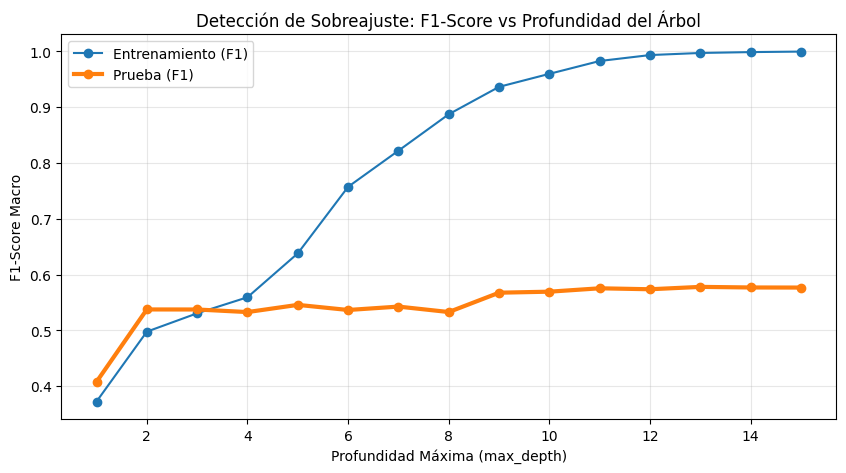

In [7]:
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(Xdf)

profundidades = range(1, 16)
train_scores = []
test_scores = []

for d in profundidades:
    # Promediamos 10 iteraciones por cada profundidad
    t_iter, v_iter = [], []
    for i in range(10):
        xt, xv, yt, yv = train_test_split(X_prep, ydf, test_size=0.2, random_state=i)
        dt = DecisionTreeClassifier(max_depth=d, random_state=42)
        dt.fit(xt, yt)
        t_iter.append(f1_score(yt, dt.predict(xt), average='macro'))
        v_iter.append(f1_score(yv, dt.predict(xv), average='macro'))
    train_scores.append(np.mean(t_iter))
    test_scores.append(np.mean(v_iter))

plt.figure(figsize=(10, 5))
plt.plot(profundidades, train_scores, label='Entrenamiento (F1)', marker='o')
plt.plot(profundidades, test_scores, label='Prueba (F1)', marker='o', linewidth=3)
plt.title("Detección de Sobreajuste: F1-Score vs Profundidad del Árbol")
plt.xlabel("Profundidad Máxima (max_depth)")
plt.ylabel("F1-Score Macro")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Generando visualización de la estructura de los 10 árboles...


NameError: name 'modelos_iter' is not defined

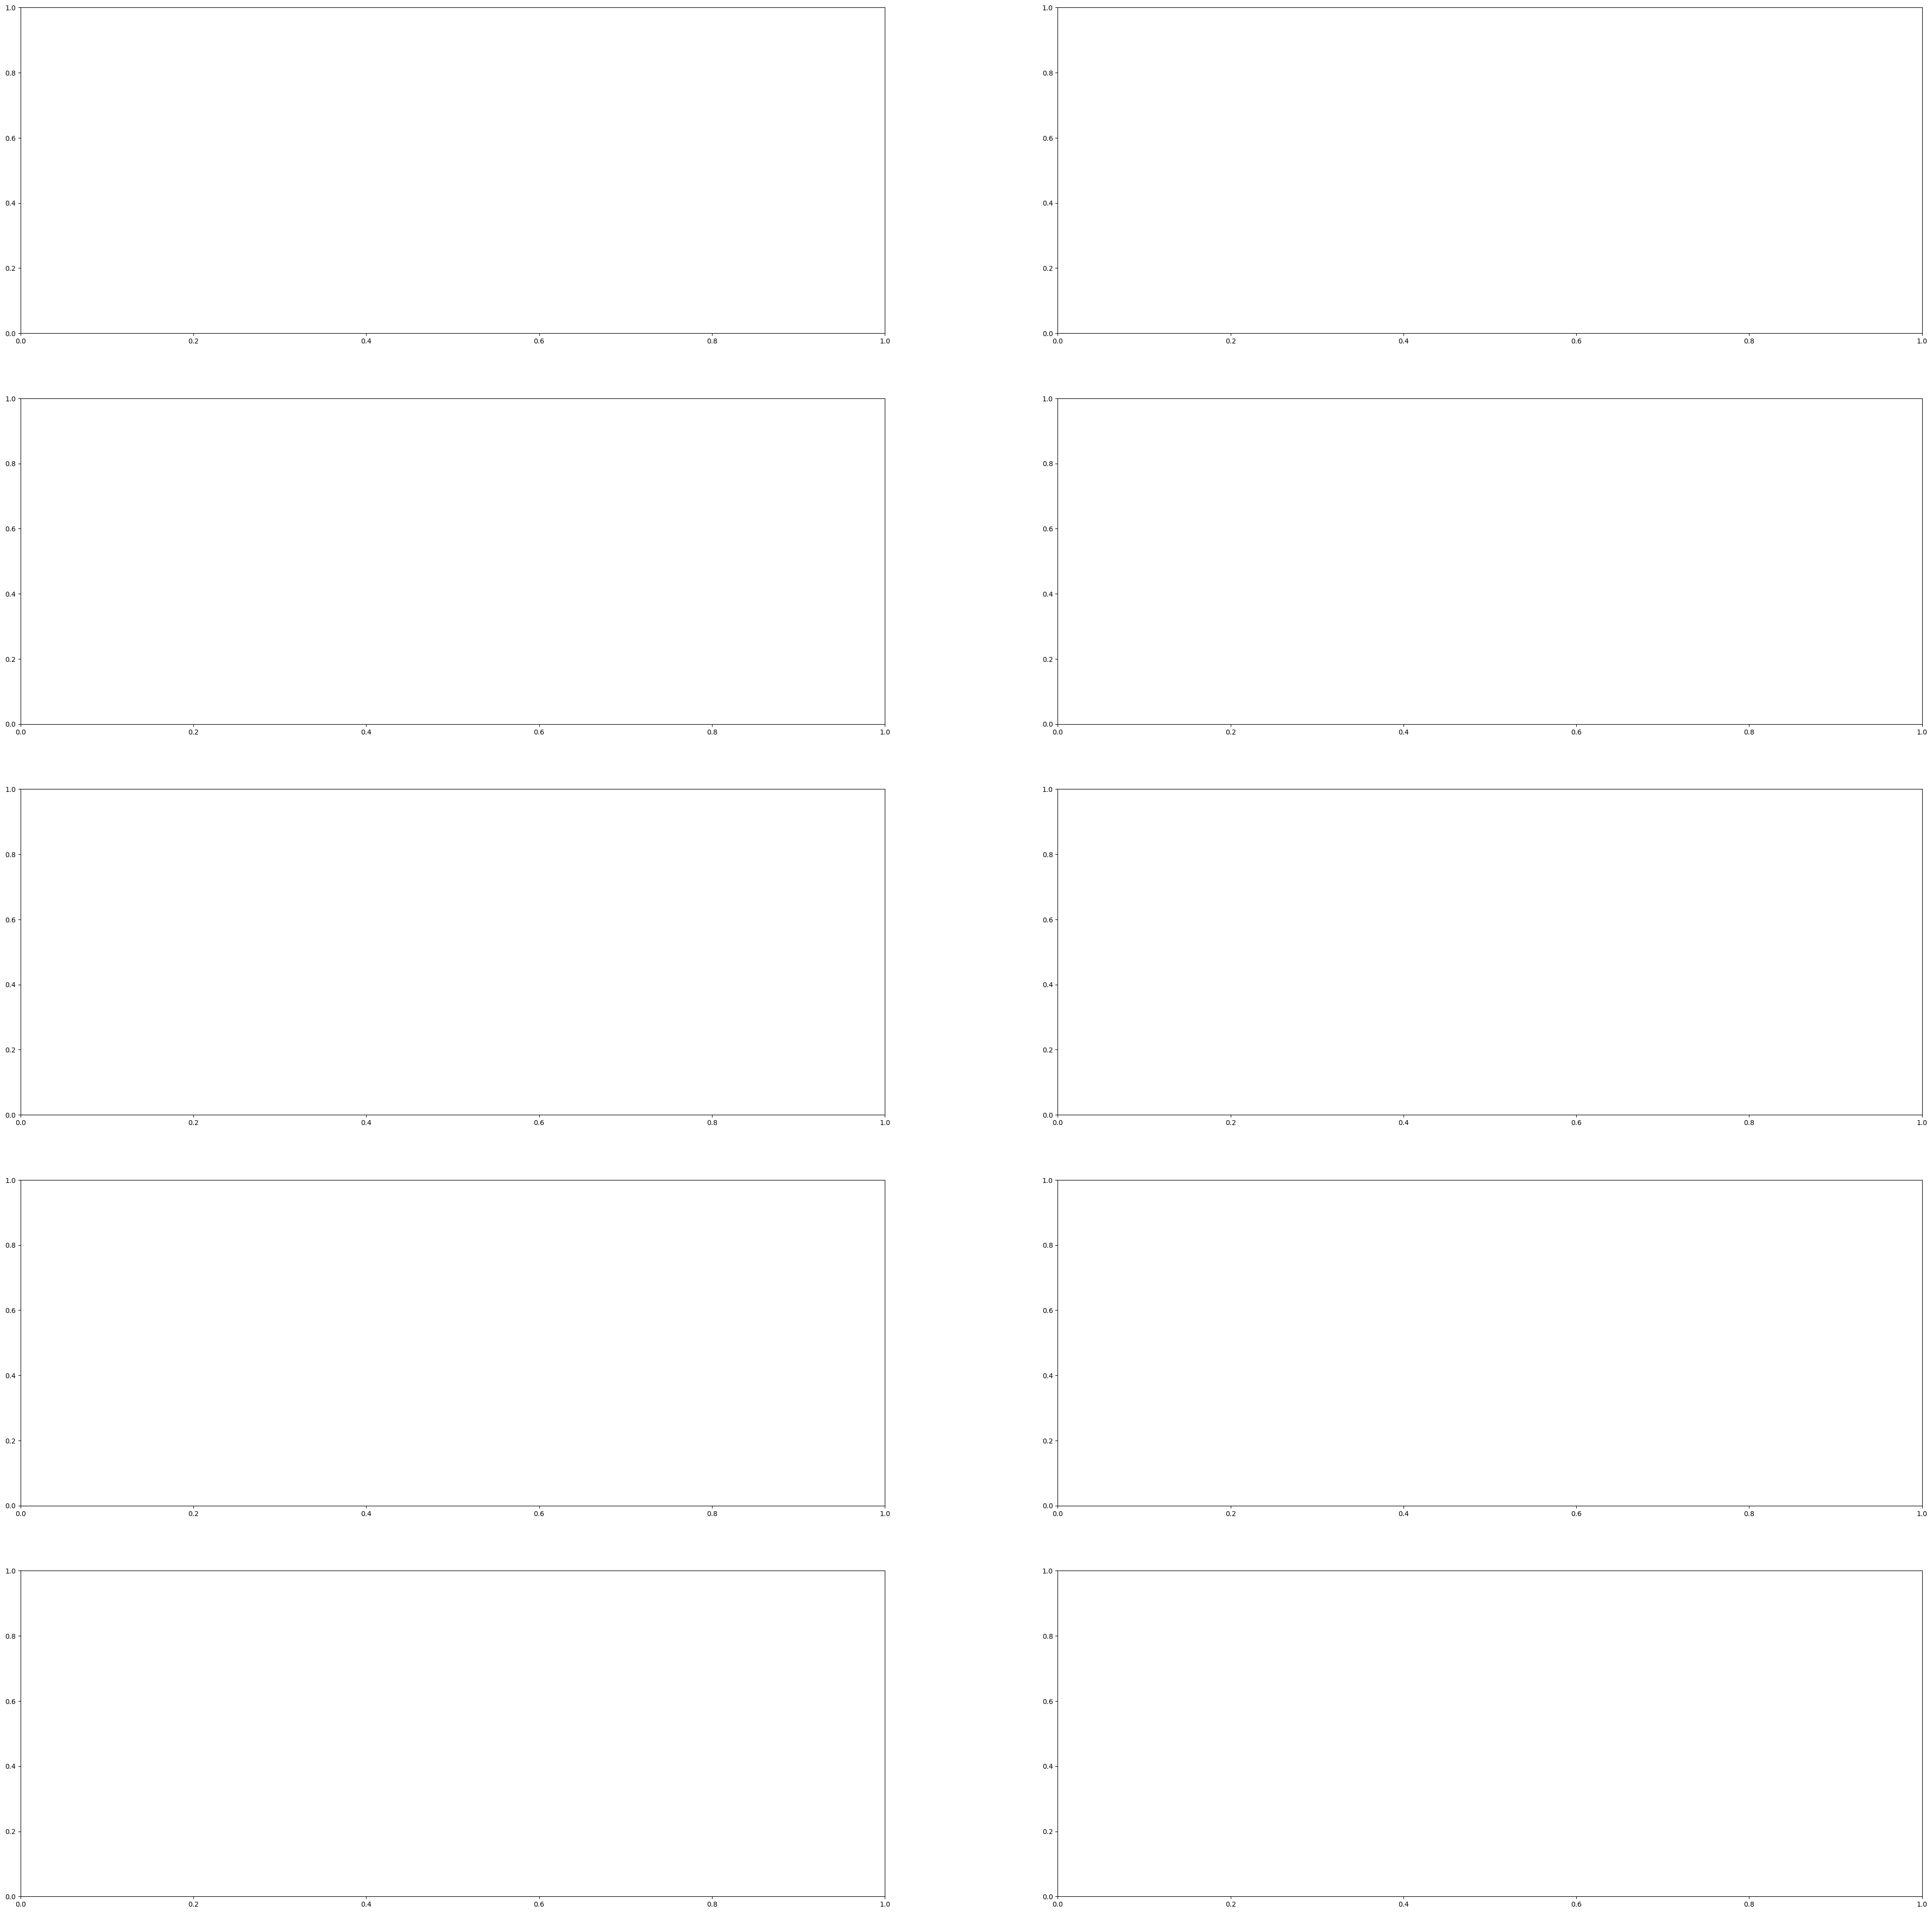

In [9]:
fig_tree, axes_tree = plt.subplots(5, 2, figsize=(50, 50))
axes_tree = axes_tree.flatten()

print("Generando visualización de la estructura de los 10 árboles...")

for i in range(10):
    # Visualizamos cada árbol entrenado en su respectivo subplot
    plot_tree(modelos_iter[i], 
              feature_names=features, 
              class_names=['Sano', 'M.Leve', 'Leve', 'Mod'], 
              filled=True, 
              rounded=True, 
              ax=axes_tree[i],
              fontsize=8)
    axes_tree[i].set_title(f"Árbol Iteración {i+1}")

fig_tree.suptitle("Estructura de los Árboles de Decisión (10 Validaciones Independientes)", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Ejecutando 10 iteraciones de validación...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is pre

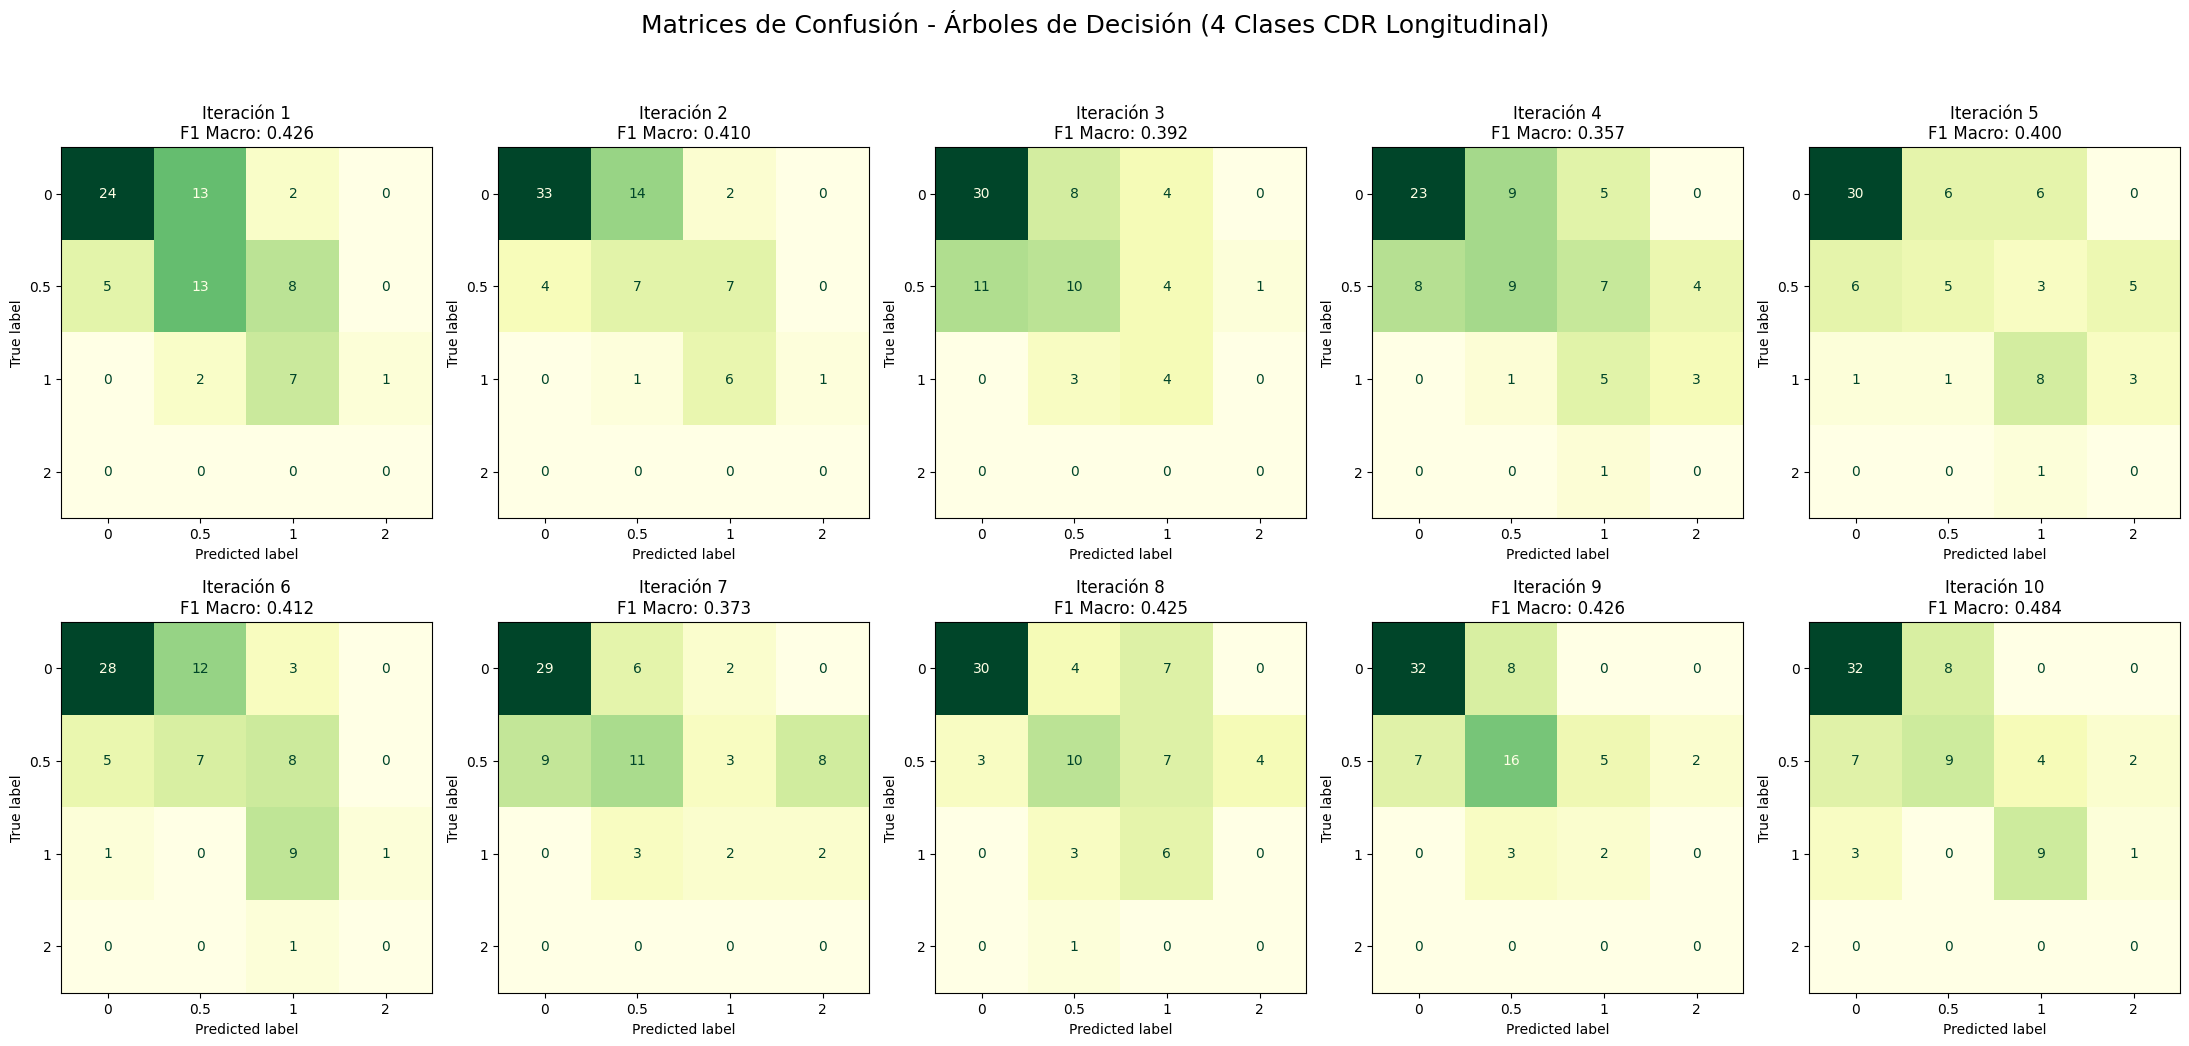


Métrica (Árbol de Decisión)    | Promedio ± DE            
------------------------------------------------------------
Accuracy                       | 0.5947 ± 0.0481
Precision (Macro)              | 0.4172 ± 0.0324
Recall (Macro)                 | 0.4271 ± 0.0374
F1-score (Macro)               | 0.4105 ± 0.0328
AUC (Macro)                    | 0.7004 ± 0.0276


In [ ]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_longi)

# 3. Configuración del Diseño Experimental (10 Validaciones Independientes 80/20) [8]
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 11))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación...")

for i in range(10):
    # Partición aleatoria única por iteración (random_state variable)
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y_longi, test_size=0.2, random_state=i
    )
    
    # 4. Entrenamiento del Árbol de Decisión (Con control de complejidad) [2]
    # Se usa class_weight='balanced' para mitigar el desbalance severo [9]
    dt = DecisionTreeClassifier(max_depth=14, 
                                min_samples_leaf=10, 
                                class_weight='balanced', 
                                random_state=42)
    dt.fit(X_train, y_train)
    
    # Predicciones
    y_pred = dt.predict(X_test)
    y_proba = dt.predict_proba(X_test)
    
    # 5. Registro de Métricas (Promedio Macro por desbalance) [5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    results['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    results['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    # Cálculo de AUC Multiclase (One-vs-Rest)
    # Binarizamos y_test para manejar las 4 clases [4, 5]
    y_test_bin = label_binarize(y_test, classes=clases_str)
    try:
        results['auc'].append(roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'))
    except ValueError:
        results['auc'].append(np.nan) # Si una clase falta en el test set de esta iteración
    
    # 6. Generación del Grid de Matrices de Confusión [Instrucción personalizada]
    cm = confusion_matrix(y_test, y_pred, labels=clases_str)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='YlGn', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1 Macro: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión - Árboles de Decisión (4 Clases CDR Longitudinal)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Reporte Final de Desempeño (Media ± DE) [10, 11]
print("\n" + "="*60)
print(f"{'Métrica (Árbol de Decisión)':<30} | {'Promedio ± DE':<25}")
print("-" * 60)
print(f"{'Accuracy':<30} | {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"{'Precision (Macro)':<30} | {np.mean(results['prec']):.4f} ± {np.std(results['prec']):.4f}")
print(f"{'Recall (Macro)':<30} | {np.mean(results['rec']):.4f} ± {np.std(results['rec']):.4f}")
print(f"{'F1-score (Macro)':<30} | {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
# Usamos nanmean para AUC debido al desbalance extremo del dataset [Turno anterior]
print(f"{'AUC (Macro)':<30} | {np.nanmean(results['auc']):.4f} ± {np.nanstd(results['auc']):.4f}")
print("="*60)

Ejecutando 10 iteraciones de validación...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is pre

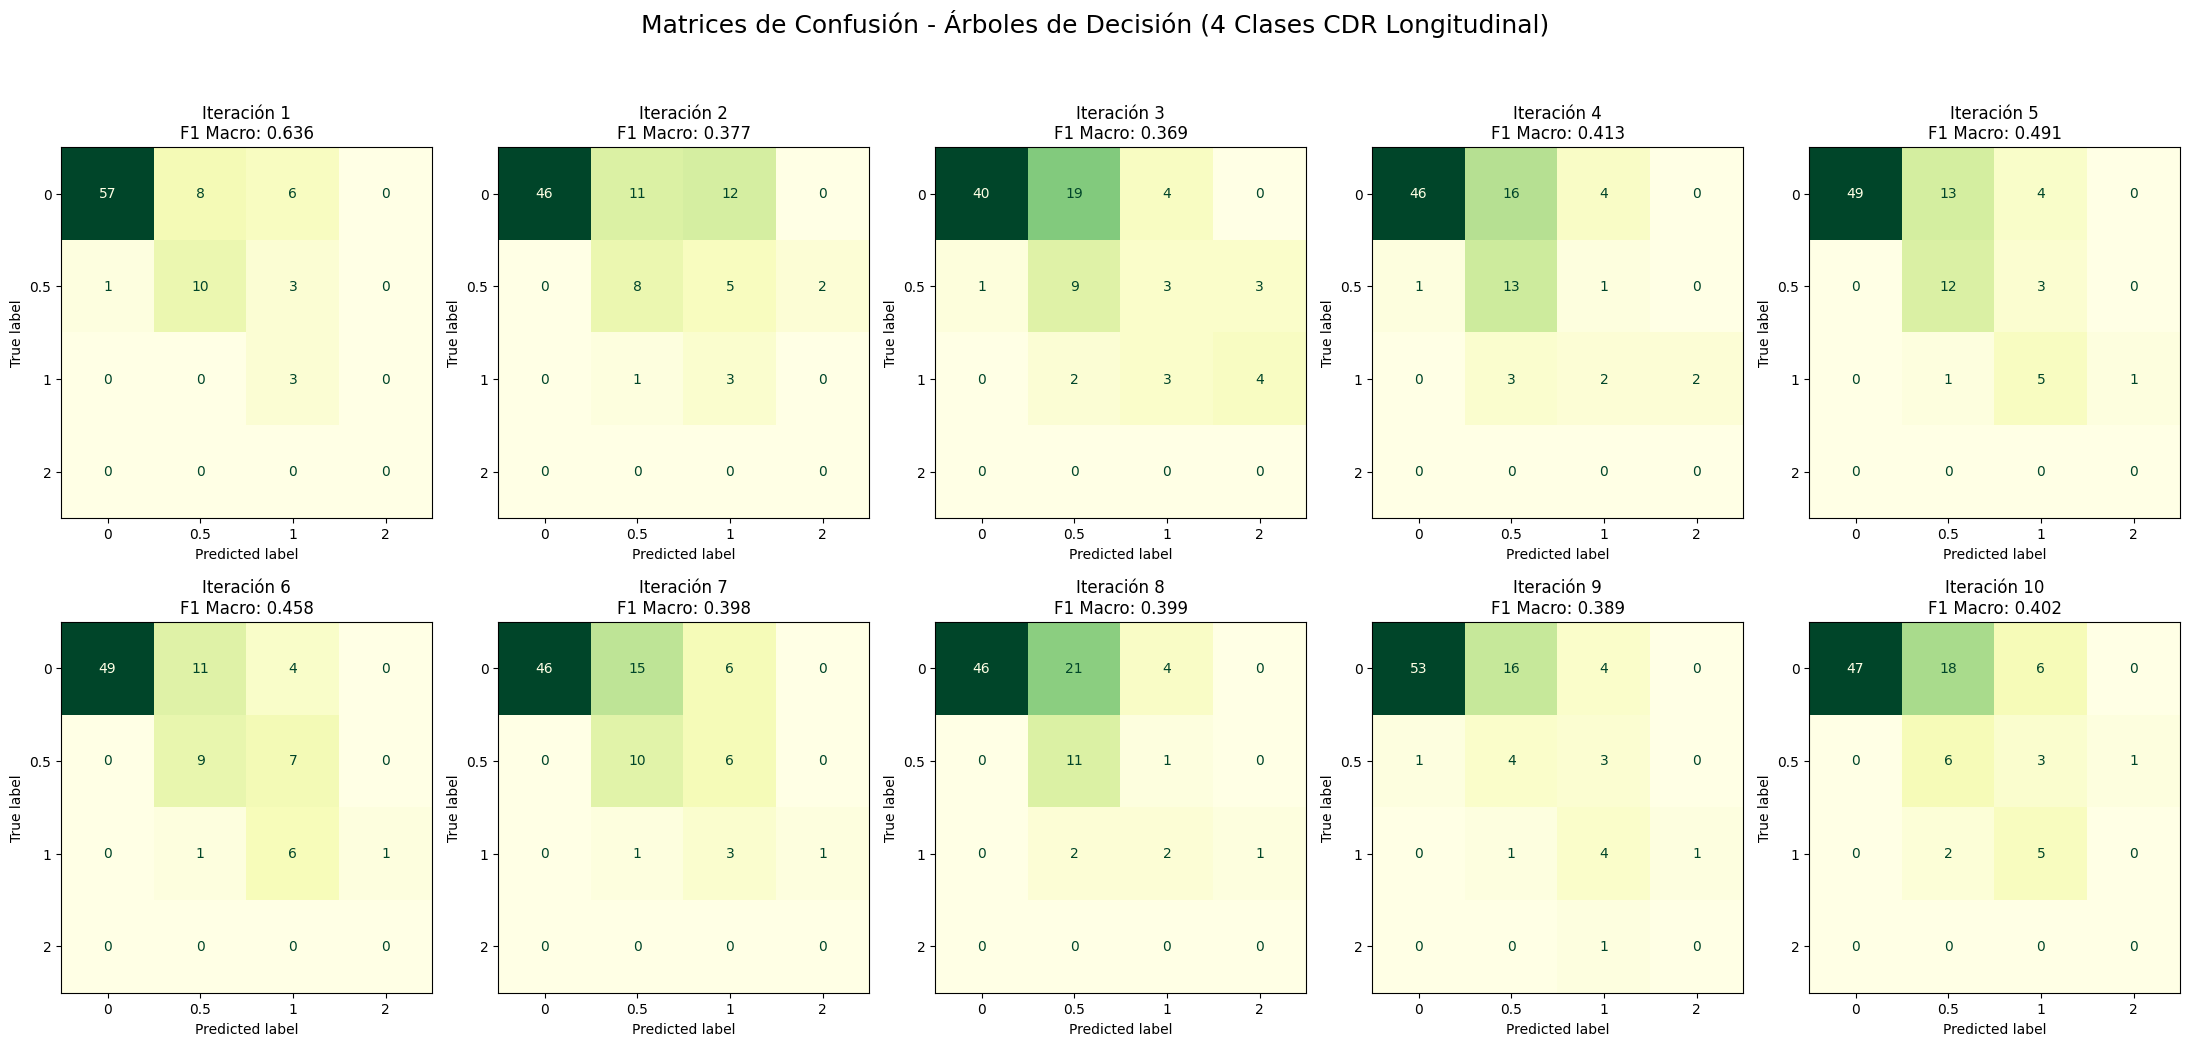


Métrica (Árbol de Decisión)    | Promedio ± DE            
------------------------------------------------------------
Accuracy                       | 0.6898 ± 0.0543
Precision (Macro)              | 0.4282 ± 0.0621
Recall (Macro)                 | 0.5192 ± 0.1151
F1-score (Macro)               | 0.4332 ± 0.0763
AUC (Macro)                    | 0.7680 ± 0.0000


In [ ]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_cross)

# 3. Configuración del Diseño Experimental (10 Validaciones Independientes 80/20) [8]
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 11))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación...")

for i in range(10):
    # Partición aleatoria única por iteración (random_state variable)
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y_cross, test_size=0.2, random_state=i
    )
    
    # 4. Entrenamiento del Árbol de Decisión (Con control de complejidad) [2]
    # Se usa class_weight='balanced' para mitigar el desbalance severo [9]
    dt = DecisionTreeClassifier(max_depth=4, 
                                min_samples_leaf=10, 
                                class_weight='balanced', 
                                random_state=42)
    dt.fit(X_train, y_train)
    
    # Predicciones
    y_pred = dt.predict(X_test)
    y_proba = dt.predict_proba(X_test)
    
    # 5. Registro de Métricas (Promedio Macro por desbalance) [5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    results['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    results['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    # Cálculo de AUC Multiclase (One-vs-Rest)
    # Binarizamos y_test para manejar las 4 clases [4, 5]
    y_test_bin = label_binarize(y_test, classes=clases_str)
    try:
        results['auc'].append(roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'))
    except ValueError:
        results['auc'].append(np.nan) # Si una clase falta en el test set de esta iteración
    
    # 6. Generación del Grid de Matrices de Confusión [Instrucción personalizada]
    cm = confusion_matrix(y_test, y_pred, labels=clases_str)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='YlGn', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1 Macro: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión - Árboles de Decisión (4 Clases CDR Longitudinal)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Reporte Final de Desempeño (Media ± DE) [10, 11]
print("\n" + "="*60)
print(f"{'Métrica (Árbol de Decisión)':<30} | {'Promedio ± DE':<25}")
print("-" * 60)
print(f"{'Accuracy':<30} | {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"{'Precision (Macro)':<30} | {np.mean(results['prec']):.4f} ± {np.std(results['prec']):.4f}")
print(f"{'Recall (Macro)':<30} | {np.mean(results['rec']):.4f} ± {np.std(results['rec']):.4f}")
print(f"{'F1-score (Macro)':<30} | {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
# Usamos nanmean para AUC debido al desbalance extremo del dataset [Turno anterior]
print(f"{'AUC (Macro)':<30} | {np.nanmean(results['auc']):.4f} ± {np.nanstd(results['auc']):.4f}")
print("="*60)

Ejecutando 10 iteraciones de validación...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


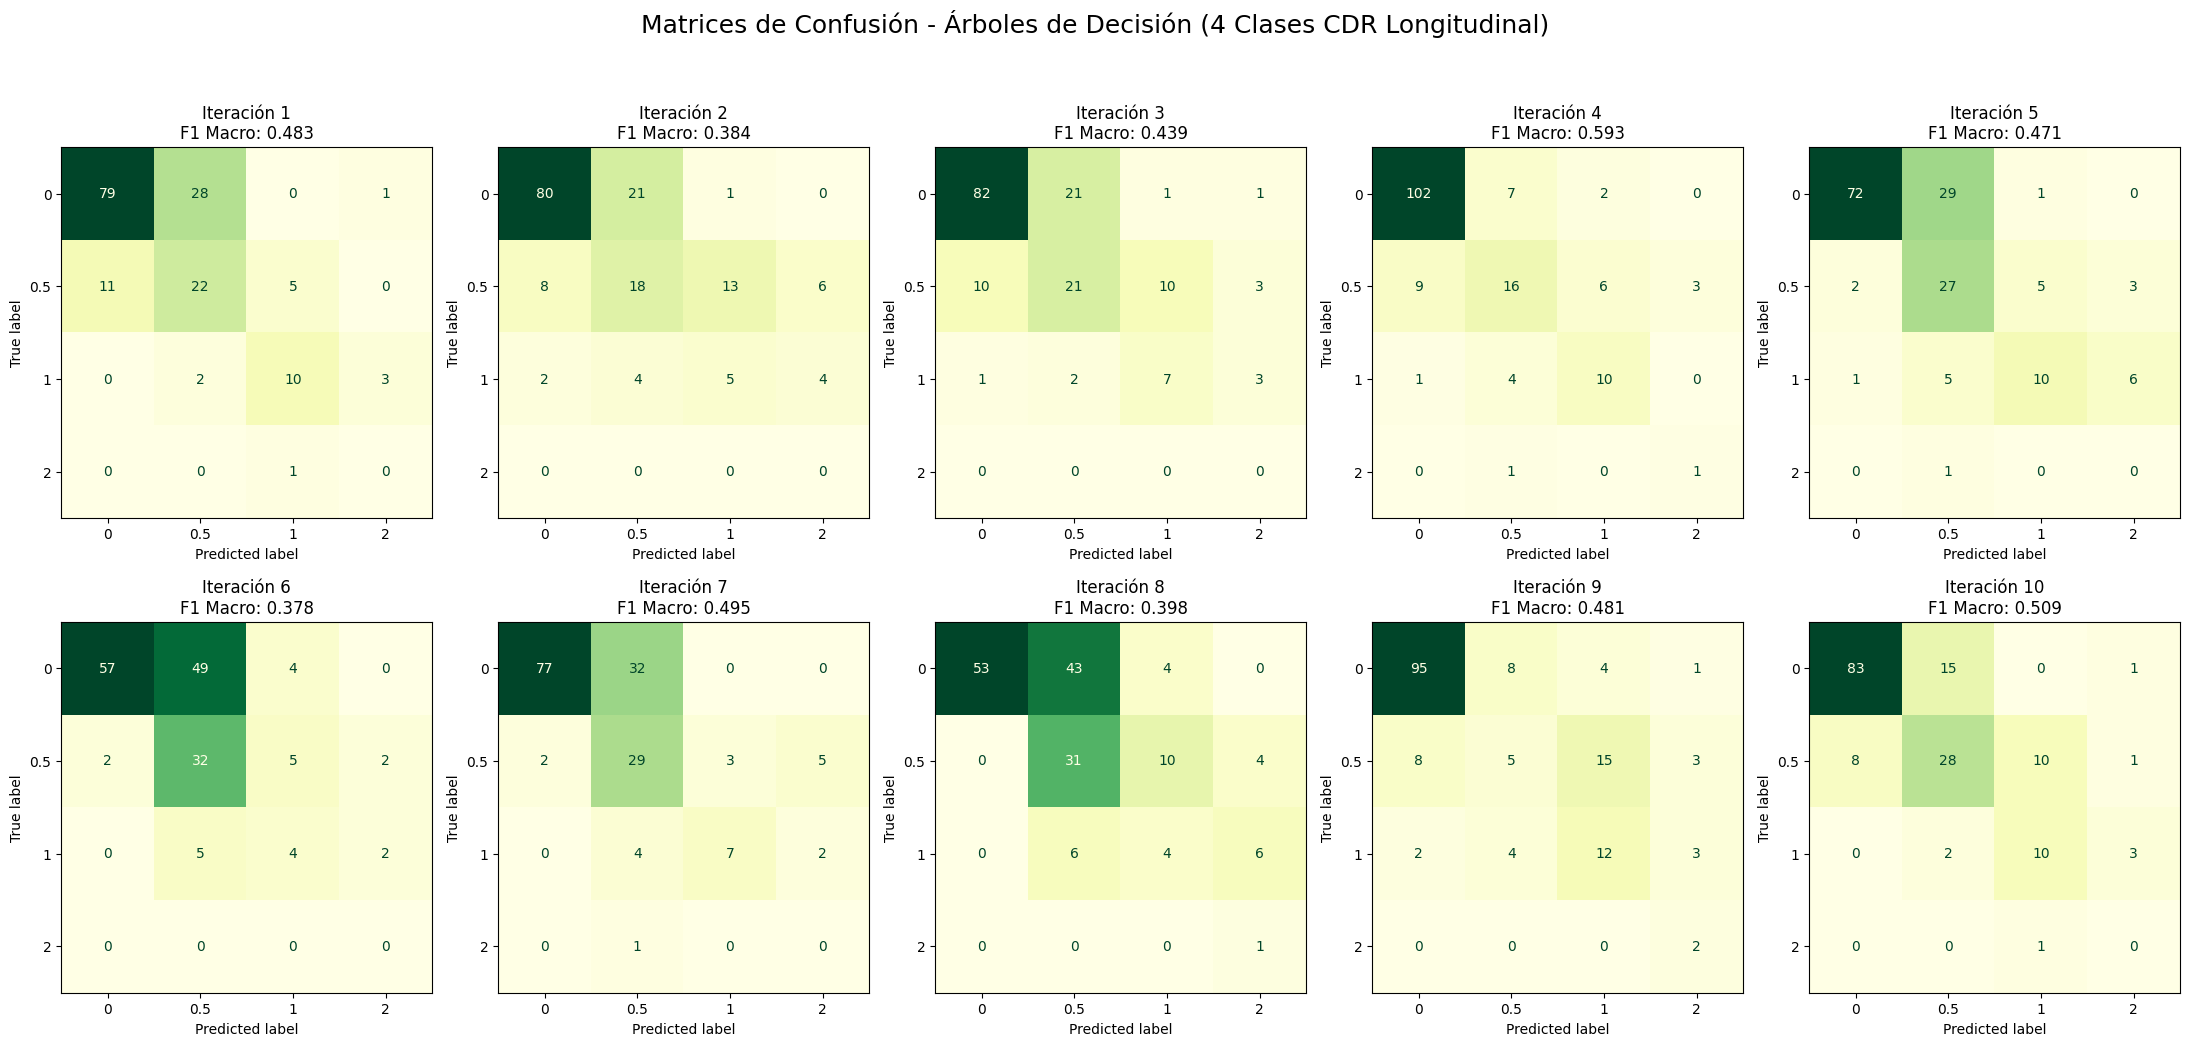


Métrica (Árbol de Decisión)    | Promedio ± DE            
------------------------------------------------------------
Accuracy                       | 0.6741 ± 0.0699
Precision (Macro)              | 0.4708 ± 0.0539
Recall (Macro)                 | 0.5143 ± 0.0895
F1-score (Macro)               | 0.4632 ± 0.0625
AUC (Macro)                    | 0.8005 ± 0.0488


In [ ]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(Xdf)

# 3. Configuración del Diseño Experimental (10 Validaciones Independientes 80/20) [8]
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 11))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación...")

for i in range(10):
    # Partición aleatoria única por iteración (random_state variable)
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, ydf, test_size=0.2, random_state=i
    )
    
    # 4. Entrenamiento del Árbol de Decisión (Con control de complejidad) [2]
    # Se usa class_weight='balanced' para mitigar el desbalance severo [9]
    dt = DecisionTreeClassifier(max_depth=4, 
                                min_samples_leaf=10, 
                                class_weight='balanced', 
                                random_state=42)
    dt.fit(X_train, y_train)
    
    # Predicciones
    y_pred = dt.predict(X_test)
    y_proba = dt.predict_proba(X_test)
    
    # 5. Registro de Métricas (Promedio Macro por desbalance) [5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    results['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    results['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    # Cálculo de AUC Multiclase (One-vs-Rest)
    # Binarizamos y_test para manejar las 4 clases [4, 5]
    y_test_bin = label_binarize(y_test, classes=clases_str)
    try:
        results['auc'].append(roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'))
    except ValueError:
        results['auc'].append(np.nan) # Si una clase falta en el test set de esta iteración
    
    # 6. Generación del Grid de Matrices de Confusión [Instrucción personalizada]
    cm = confusion_matrix(y_test, y_pred, labels=clases_str)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='YlGn', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1 Macro: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión - Árboles de Decisión (4 Clases CDR Longitudinal)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Reporte Final de Desempeño (Media ± DE) [10, 11]
print("\n" + "="*60)
print(f"{'Métrica (Árbol de Decisión)':<30} | {'Promedio ± DE':<25}")
print("-" * 60)
print(f"{'Accuracy':<30} | {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"{'Precision (Macro)':<30} | {np.mean(results['prec']):.4f} ± {np.std(results['prec']):.4f}")
print(f"{'Recall (Macro)':<30} | {np.mean(results['rec']):.4f} ± {np.std(results['rec']):.4f}")
print(f"{'F1-score (Macro)':<30} | {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
# Usamos nanmean para AUC debido al desbalance extremo del dataset [Turno anterior]
print(f"{'AUC (Macro)':<30} | {np.nanmean(results['auc']):.4f} ± {np.nanstd(results['auc']):.4f}")
print("="*60)